<a href="https://colab.research.google.com/github/2403A52058/NLP_LABASSIGNMENTS/blob/main/NLP_LAB_10_2403A52058.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install Required Libraries

In [1]:
"""
 Install Required Libraries

This installs gensim if not already available.
"""

!pip install gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 28.6 MB/s eta 0:00:00


Import Required Libraries

In [3]:
"""
 Import Libraries

pandas       → To read CSV dataset
gensim       → To load pre-trained embeddings
numpy        → Numerical operations
matplotlib   → Visualization
TSNE         → Dimensionality reduction
"""

import pandas as pd
import gensim.downloader as api
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE


Load Dataset

In [5]:
"""
 Load Word Dataset

This reads words from the uploaded CSV file.
Make sure the CSV contains one column of words.
"""

# Load dataset
file_path = "/content/word_list_tsne.csv"
df = pd.read_csv(file_path)

# Display first few rows
print("Dataset Preview:")
print(df.head())

# Convert column to list
# (Assuming first column contains words)
word_list = df.iloc[:, 0].dropna().tolist()

print("\nTotal Words Loaded:", len(word_list))
print("\nSample Words:", word_list[:10])


Dataset Preview:
       word
0       dog
1       cat
2      lion
3     tiger
4  elephant

Total Words Loaded: 39

Sample Words: ['dog', 'cat', 'lion', 'tiger', 'elephant', 'horse', 'cow', 'monkey', 'apple', 'banana']


Load Pre-trained Embedding Model

In [6]:
"""
 Load Pre-trained Word Embeddings

We use GloVe (100-dimensional vectors).
Each word is represented as a 100D numerical vector.
"""

model = api.load("glove-wiki-gigaword-100")

print("Vocabulary Size of Model:", len(model))

# Example vector
print("\nExample vector for 'king':")
print(model["king"])


[==================================================] 100.0% 128.1/128.1MB downloaded
Vocabulary Size of Model: 400000

Example vector for 'king':
[-0.32307  -0.87616   0.21977   0.25268   0.22976   0.7388   -0.37954
 -0.35307  -0.84369  -1.1113   -0.30266   0.33178  -0.25113   0.30448
 -0.077491 -0.89815   0.092496 -1.1407   -0.58324   0.66869  -0.23122
 -0.95855   0.28262  -0.078848  0.75315   0.26584   0.3422   -0.33949
  0.95608   0.065641  0.45747   0.39835   0.57965   0.39267  -0.21851
  0.58795  -0.55999   0.63368  -0.043983 -0.68731  -0.37841   0.38026
  0.61641  -0.88269  -0.12346  -0.37928  -0.38318   0.23868   0.6685
 -0.43321  -0.11065   0.081723  1.1569    0.78958  -0.21223  -2.3211
 -0.67806   0.44561   0.65707   0.1045    0.46217   0.19912   0.25802
  0.057194  0.53443  -0.43133  -0.34311   0.59789  -0.58417   0.068995
  0.23944  -0.85181   0.30379  -0.34177  -0.25746  -0.031101 -0.16285
  0.45169  -0.91627   0.64521   0.73281  -0.22752   0.30226   0.044801
 -0.83741   0.

Extract Word Vectors

In [7]:
"""
 Extract Word Vectors

For each word in dataset:
- Check if it exists in embedding vocabulary
- Store corresponding vector
"""

vectors = []
valid_words = []

for word in word_list:
    if word in model:
        vectors.append(model[word])
        valid_words.append(word)
    else:
        print(f"{word} not found in embedding model")

# Convert to numpy array
vectors = np.array(vectors)

print("\nValid Words Used:", len(valid_words))
print("Vector Shape:", vectors.shape)



Valid Words Used: 39
Vector Shape: (39, 100)


Apply t-SNE

In [8]:
"""
 Apply t-SNE

Reduce 100-dimensional vectors → 2D
t-SNE preserves similarity between nearby words.
"""

tsne = TSNE(n_components=2, random_state=42, perplexity=15)

reduced_vectors = tsne.fit_transform(vectors)

print("Shape After t-SNE:", reduced_vectors.shape)


Shape After t-SNE: (39, 2)


Plot t-SNE Visualization

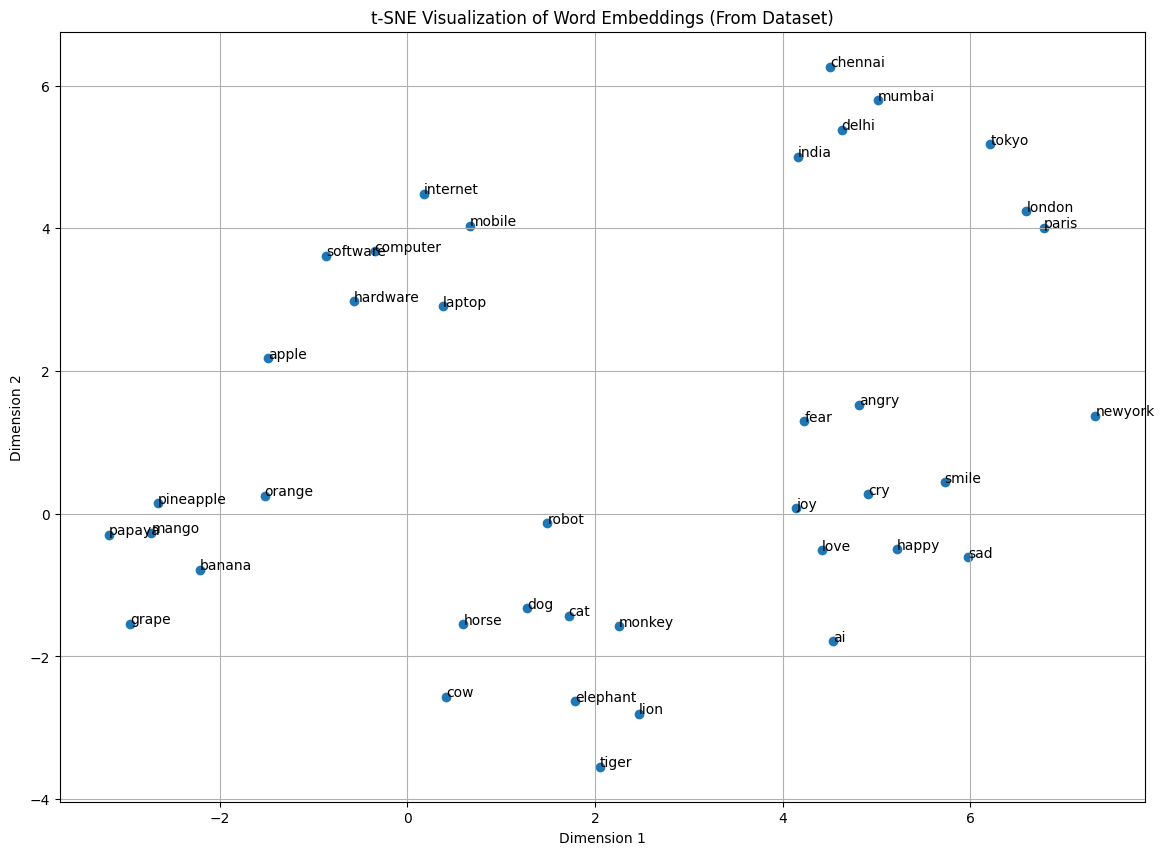

In [9]:
"""
Plot 2D Word Embeddings

Creates scatter plot and annotates each word.
"""

plt.figure(figsize=(14, 10))

# Scatter plot
plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1])

# Add word labels
for i, word in enumerate(valid_words):
    plt.annotate(word,
                 (reduced_vectors[i, 0], reduced_vectors[i, 1]))

plt.title("t-SNE Visualization of Word Embeddings (From Dataset)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True)
plt.show()
